# Graph creation 

This notebook builds structural EEG graphs from per-channel features, visualizes electrode layouts


In [27]:
# Setup and imports
import sys
from pathlib import Path
import os
import json

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

# Project root detection (works when running from notebooks/ folder)
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))
print(f"Project root: {project_root}")

Project root: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech


In [28]:
# Load feature dataframe and basic cleaning
df_features_path = project_root / "data/processed/comprehensive_features_subjects.csv"
if not df_features_path.exists():
    raise FileNotFoundError(f"Features file not found: {df_features_path}")

df_features = pd.read_csv(df_features_path)
print(f"✓ Loaded comprehensive features from {df_features_path} ({len(df_features)} rows)")

# Ensure subject/session/epoch numeric
for col in ["subject_id", "session_id", "epoch_idx"]:
    df_features[col] = pd.to_numeric(df_features[col], errors="coerce")
before_drop = len(df_features)
df_features = df_features.dropna(subset=["subject_id", "session_id", "epoch_idx"])
print(f"✓ Dropped {before_drop - len(df_features)} rows with non-numeric subject/session/epoch")
df_features[["subject_id", "session_id", "epoch_idx"]] = df_features[["subject_id", "session_id", "epoch_idx"]].astype(int)

/var/folders/nf/98xxwv1511dfz5j4f3x3jqgc0000gn/T/ipykernel_6860/4141011067.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_features = pd.read_csv(df_features_path)


✓ Loaded comprehensive features from /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/processed/comprehensive_features_subjects.csv (2361066 rows)
✓ Dropped 8784 rows with non-numeric subject/session/epoch
✓ Dropped 8784 rows with non-numeric subject/session/epoch


In [29]:
# Channel mapping and label alignment
channel_map_path = project_root / "data/interim/channel_mapping.csv"
if not channel_map_path.exists():
    raise FileNotFoundError(f"Channel mapping file not found: {channel_map_path}")
mapping = pd.read_csv(channel_map_path)
required_cols = {"h5_name", "eloc_name"}
if not required_cols.issubset(set(mapping.columns)):
    raise ValueError(f"channel_mapping.csv must contain columns {required_cols}, found {mapping.columns.tolist()}")
map_dict = dict(zip(mapping["h5_name"], mapping["eloc_name"]))
df_features["channel_std"] = df_features["channel"].map(map_dict)
before_drop_ch = len(df_features)
df_features = df_features.dropna(subset=["channel_std"])
print(f"✓ Dropped {before_drop_ch - len(df_features)} rows with unmapped channels")

# Load label2idx and derive label_word
label2idx_path = project_root / "data/interim/label2idx.json"
if not label2idx_path.exists():
    raise FileNotFoundError(f"Label2idx file not found: {label2idx_path}")
with open(label2idx_path, "r") as f:
    label2idx = json.load(f)
idx2label = {v: k for k, v in label2idx.items()}
df_features["label_word"] = df_features["label_name"].str.replace("_img$", "", regex=True)
df_features["label_id"] = df_features["label_word"].map(label2idx)
missing_label_ids = df_features["label_id"].isna().sum()
if missing_label_ids > 0:
    missing_words = df_features.loc[df_features["label_id"].isna(), "label_word"].unique().tolist()
    print("⚠ WARNING:", missing_label_ids, "rows with label_word not found in label2idx.")
    print("Missing words:", missing_words)
before_drop_lbl = len(df_features)
df_features = df_features.dropna(subset=["label_id"])
print(f"✓ Dropped {before_drop_lbl - len(df_features)} rows with unknown labels")
df_features["label_id"] = df_features["label_id"].astype(int)

✓ Dropped 0 rows with unmapped channels
✓ Dropped 0 rows with unknown labels
✓ Dropped 0 rows with unknown labels


In [30]:
# Build epoch-level tensors: X_epochs, y_epochs, meta_epochs
out_path = project_root / "data/processed/eeg_epoch_tensors.pt"

if out_path.exists():
    print(f"Tensor file already exists at {out_path}. Loading...")
    data = torch.load(out_path)
    X_epochs = data["X_epochs"]
    y_epochs = data["y_epochs"]
    if isinstance(y_epochs, torch.Tensor):
        y_epochs = y_epochs.tolist()
    meta_epochs = data["meta_epochs"]
    feature_cols = data["feature_cols"]
    print(f"✓ Loaded {len(X_epochs)} epoch tensors")
else:
    print(f"Tensor file not found. Creating...")
    group_cols = ["subject_id", "session_id", "epoch_idx"]
    df_sorted = df_features.sort_values(group_cols + ["channel_std"])
    meta_cols = ["subject_id", "session_id", "epoch_idx", "channel", "channel_std", "label_name", "label_word", "label_id"]
    feature_cols = [c for c in df_features.columns if c not in meta_cols]
    X_epochs = []
    y_epochs = []
    meta_epochs = []
    for keys, g in df_sorted.groupby(group_cols):
        subject_id, session_id, epoch_idx = keys
        x_np = g[feature_cols].values
        x = torch.tensor(x_np, dtype=torch.float32)
        label_id = int(g["label_id"].iloc[0])
        X_epochs.append(x)
        y_epochs.append(label_id)
        meta_epochs.append({"subject_id": int(subject_id), "session_id": int(session_id), "epoch_idx": int(epoch_idx)})
    print(f"✓ Built {len(X_epochs)} epoch tensors")
    print("First epoch shape:", X_epochs[0].shape)
    
    # Save tensors
    out_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"X_epochs": X_epochs, "y_epochs": torch.tensor(y_epochs, dtype=torch.long), "meta_epochs": meta_epochs, "feature_cols": feature_cols, "label2idx": label2idx}, out_path)
    print(f"✓ Saved epoch tensors to {out_path}")

Tensor file already exists at /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/processed/eeg_epoch_tensors.pt. Loading...
✓ Loaded 38562 epoch tensors
✓ Loaded 38562 epoch tensors


In [31]:
# Saving is now handled in the previous cell to avoid re-computation
pass

In [32]:
out_path = project_root / "data/processed/eeg_epoch_tensors.pt"

torch.load(out_path)  # Test loading
print("✓ Successfully loaded saved epoch tensors")

✓ Successfully loaded saved epoch tensors


# Clustering + MLP + LOGREG

In [43]:
true_labels = [
    "arrivare","andare","aspettare","avere","capire","chiamare","chiedere",
    "conoscere","dare","dire","dovere","essere","fare","mettere","potere",
    "prendere","sapere","sentire","trovare","venire","aprire","chiudere",
    "mangiare","bere","accendere","spegnere","volere","bene","si","no",
    "più","poco","molto","sempre","adesso","poi","male","sopra","sotto",
    "destra","sinistra","avanti","indietro","oggi","domani","ieri","forse",
    "prima","perchè","anche","come","però","quindi","quando","dove","se",
    "oppure","io","lui","lei","noi","voi","loro","tu","questo","quello",
    "buono","bello","cattivo","brutto","grande","piccolo","nuovo","vecchio",
    "cosa","parte","anno","casa","problema","aiuto","tempo","lavoro",
    "persona","acqua","cibo","bisogno","donna","uomo","gruppo","guerra",
    "idea","macchina","mano","oggetto","telefono","computer","domanda",
    "uno","mille","paura","ansia","gioia","felicità","tristezza",
    "serenità","amore","morte","bagno","dolore","riposo"
]

# 1) embeddings semantici con Sentence-BERT multilingua
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

emb = model.encode(true_labels, normalize_embeddings=True)   # [num_words, dim]


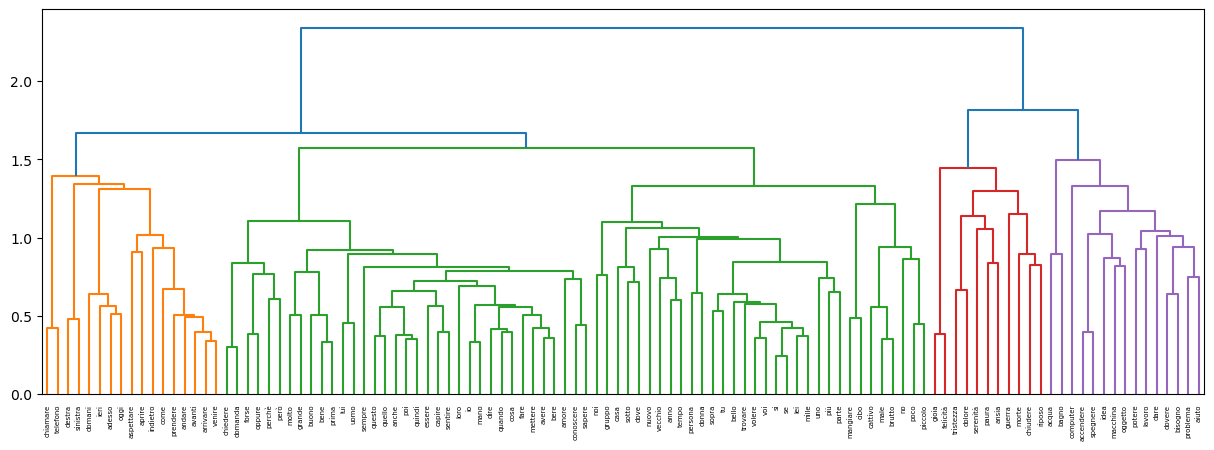


=== CLUSTER 0 ===
arrivare, andare, aspettare, chiamare, prendere, venire, aprire, adesso, destra, sinistra, avanti, indietro, oggi, domani, ieri, come, telefono

=== CLUSTER 1 ===
avere, capire, chiedere, conoscere, dire, essere, fare, mettere, sapere, sentire, trovare, mangiare, bere, volere, bene, si, no, più, poco, molto, sempre, poi, male, sopra, sotto, forse, prima, perchè, anche, però, quindi, quando, dove, se, oppure, io, lui, lei, noi, voi, loro, tu, questo, quello, buono, bello, cattivo, brutto, grande, piccolo, nuovo, vecchio, cosa, parte, anno, casa, tempo, persona, cibo, donna, uomo, gruppo, mano, domanda, uno, mille, amore

=== CLUSTER 3 ===
dare, dovere, potere, accendere, spegnere, problema, aiuto, lavoro, acqua, bisogno, idea, macchina, oggetto, computer, bagno

=== CLUSTER 2 ===
chiudere, guerra, paura, ansia, gioia, felicità, tristezza, serenità, morte, dolore, riposo


In [44]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from collections import defaultdict

# embeddings
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
emb = model.encode(true_labels, normalize_embeddings=True)

# 1) clustering gerarchico
Z = linkage(emb, method="ward")
plt.figure(figsize=(15,5))
dendrogram(Z, labels=true_labels, leaf_rotation=90)
plt.show()

# 2) taglia l'albero in modo da avere ESATTAMENTE 4 cluster
cluster_ids = fcluster(Z, t=4, criterion="maxclust")  # cluster_id = 1..4
cluster_ids = cluster_ids - 1  # opzionale: 0..3

# 3) raggruppa parole per cluster e stampa
cluster2words = defaultdict(list)
for w, c in zip(true_labels, cluster_ids):
    cluster2words[c].append(w)

for c, words in cluster2words.items():
    print(f"\n=== CLUSTER {c} ===")
    print(", ".join(words))

In [45]:
true_labels = [
    "arrivare","andare","aspettare","avere","capire","chiamare","chiedere",
    "conoscere","dare","dire","dovere","essere","fare","mettere","potere",
    "prendere","sapere","sentire","trovare","venire","aprire","chiudere",
    "mangiare","bere","accendere","spegnere","volere","bene","si","no",
    "più","poco","molto","sempre","adesso","poi","male","sopra","sotto",
    "destra","sinistra","avanti","indietro","oggi","domani","ieri","forse",
    "prima","perchè","anche","come","però","quindi","quando","dove","se",
    "oppure","io","lui","lei","noi","voi","loro","tu","questo","quello",
    "buono","bello","cattivo","brutto","grande","piccolo","nuovo","vecchio",
    "cosa","parte","anno","casa","problema","aiuto","tempo","lavoro",
    "persona","acqua","cibo","bisogno","donna","uomo","gruppo","guerra",
    "idea","macchina","mano","oggetto","telefono","computer","domanda",
    "uno","mille","paura","ansia","gioia","felicità","tristezza",
    "serenità","amore","morte","bagno","dolore","riposo",
]

from sentence_transformers import SentenceTransformer
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import KMeans
from collections import defaultdict
import numpy as np
import json

# ------------------------------------------------------------------
# 1) Embedding delle parole (se non li hai già in memoria)
# ------------------------------------------------------------------
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
emb = model.encode(true_labels, normalize_embeddings=True)   # [num_words, dim]

# ------------------------------------------------------------------
# 2) Clustering gerarchico -> 4 cluster "grossi" (come prima)
# ------------------------------------------------------------------
Z = linkage(emb, method="ward")
cluster_ids_4 = fcluster(Z, t=4, criterion="maxclust")  # 1..4
cluster_ids_4 = cluster_ids_4 - 1                       # 0..3

# Per riferimento, stampiamo i 4 cluster
cluster2words_4 = defaultdict(list)
for w, c in zip(true_labels, cluster_ids_4):
    cluster2words_4[c].append(w)

print("=== CLUSTER A 4 CLASSI ===")
for c, words in cluster2words_4.items():
    print(f"\nCLUSTER {c}:")
    print(", ".join(words))

# ------------------------------------------------------------------
# 3) Splitta SOLO il cluster 1 in 2 sottocluster (k=2)
# ------------------------------------------------------------------
# indici delle parole che stanno nel cluster 1
idx_c1 = [i for i, c in enumerate(cluster_ids_4) if c == 1]

# embedding delle parole dentro il cluster 1
emb_c1 = emb[idx_c1]

# KMeans con 2 sottocluster
k_sub = 2
km_sub = KMeans(n_clusters=k_sub, random_state=42, n_init=10)
sub_ids = km_sub.fit_predict(emb_c1)   # valori 0 o 1

# mappa: indice della parola -> sottocluster (0 o 1)
sub_map = {idx_c1[j]: int(sub_ids[j]) for j in range(len(idx_c1))}

# ------------------------------------------------------------------
# 4) Costruisci nuovi cluster "fini" (5 cluster totali)
# ------------------------------------------------------------------
# Scelta numerazione:
#  - 0: vecchio cluster 0 (movimento/spazio/tempo breve)
#  - 1: vecchio cluster 3 (bisogni/oggetti/compiti)
#  - 2: vecchio cluster 2 (emozioni/stati interni)
#  - 3: sottocluster 1A (dal vecchio cluster 1)
#  - 4: sottocluster 1B (dal vecchio cluster 1)

new_cluster_ids = np.zeros_like(cluster_ids_4)

for i, c in enumerate(cluster_ids_4):
    if c == 0:
        new_c = 0
    elif c == 3:
        new_c = 1
    elif c == 2:
        new_c = 2
    elif c == 1:
        # guardo a quale sottocluster appartiene questa parola
        sub = sub_map[i]   # 0 o 1
        if sub == 0:
            new_c = 3
        else:
            new_c = 4
    else:
        raise ValueError("Cluster inatteso:", c)

    new_cluster_ids[i] = new_c

# ------------------------------------------------------------------
# 5) Visualizza i cluster finali (5 classi)
# ------------------------------------------------------------------
cluster2words_5 = defaultdict(list)
for w, c in zip(true_labels, new_cluster_ids):
    cluster2words_5[c].append(w)

print("\n\n=== CLUSTER FINALI A 5 CLASSI ===")
for c, words in cluster2words_5.items():
    print(f"\nCLUSTER {c}:")
    print(", ".join(words))

# ------------------------------------------------------------------
# 6) Dizionario finale parola -> cluster_id
# ------------------------------------------------------------------
word2cluster_fine = {w: int(c) for w, c in zip(true_labels, new_cluster_ids)}

# Salva la mappatura su disco così può essere riutilizzata in altre celle/notebook
out_cluster_path = project_root / "data/interim/word2cluster_fine.json"
out_cluster_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_cluster_path, "w", encoding="utf-8") as f:
    json.dump(word2cluster_fine, f, ensure_ascii=False, indent=2)
print(f"Saved semantic cluster mapping to {out_cluster_path}")

print("\nEsempio mapping:")
for w in true_labels[:10]:
    print(w, "->", word2cluster_fine[w])


=== CLUSTER A 4 CLASSI ===

CLUSTER 0:
arrivare, andare, aspettare, chiamare, prendere, venire, aprire, adesso, destra, sinistra, avanti, indietro, oggi, domani, ieri, come, telefono

CLUSTER 1:
avere, capire, chiedere, conoscere, dire, essere, fare, mettere, sapere, sentire, trovare, mangiare, bere, volere, bene, si, no, più, poco, molto, sempre, poi, male, sopra, sotto, forse, prima, perchè, anche, però, quindi, quando, dove, se, oppure, io, lui, lei, noi, voi, loro, tu, questo, quello, buono, bello, cattivo, brutto, grande, piccolo, nuovo, vecchio, cosa, parte, anno, casa, tempo, persona, cibo, donna, uomo, gruppo, mano, domanda, uno, mille, amore

CLUSTER 3:
dare, dovere, potere, accendere, spegnere, problema, aiuto, lavoro, acqua, bisogno, idea, macchina, oggetto, computer, bagno

CLUSTER 2:
chiudere, guerra, paura, ansia, gioia, felicità, tristezza, serenità, morte, dolore, riposo


=== CLUSTER FINALI A 5 CLASSI ===

CLUSTER 0:
arrivare, andare, aspettare, chiamare, prendere, ven

## Semantic clustering of imagined words

To reduce the complexity of the decoding task (110 distinct words, 5 trials per word and subject) and to obtain neuro-cognitively meaningful targets, we grouped the words into a small set of semantic clusters.

### Step 1 – Semantic embeddings

We started from the list of 110 Italian words used in the imagined speech paradigm (e.g., *andare, casa, acqua, aiuto, amore, paura*).  
Each word was encoded into a semantic vector using a multilingual Sentence-BERT model (`paraphrase-multilingual-MiniLM-L12-v2`).  
These embeddings capture distributional semantic similarity: words that tend to occur in similar linguistic contexts are mapped to nearby points in the embedding space.

### Step 2 – Hierarchical clustering and 4 macro-clusters

On top of the embeddings we applied hierarchical clustering (Ward linkage) and inspected the dendrogram.  
The tree showed a clear structure with four major branches, which we interpreted as four macro-clusters:

1. **Movement / space / near time**  
   - Examples: *arrivare, andare, aspettare, venire, aprire, oggi, domani, ieri, destra, sinistra, avanti, indietro, telefono*.  
   - These words are mainly related to actions, spatial orientation and short-term temporal concepts.

2. **General and functional language**  
   - Examples: *avere, essere, fare, dire, sapere, si, no, più, poco, molto, io, tu, lui, noi, voi, loro, questo, quello, bello, brutto, grande, piccolo, cosa, anno, tempo, persona, domanda, uno, mille, amore*.  
   - This large cluster contains high-frequency verbs, function words (pronouns, adverbs, connectives) and generic abstract concepts.

3. **Objects, needs and instrumental actions**  
   - Examples: *dare, dovere, potere, accendere, spegnere, problema, aiuto, lavoro, acqua, bisogno, idea, macchina, oggetto, computer, bagno*.  
   - The words in this group mostly refer to concrete objects, resources, practical tasks and needs.

4. **Emotions and internal states**  
   - Examples: *paura, ansia, gioia, felicità, tristezza, serenità, morte, dolore, riposo, guerra*.  
   - This cluster aggregates emotional states, affective experiences and other internally oriented concepts.

These four clusters already provide a meaningful semantic structure that is compatible with different large-scale brain networks (motor/spatial, language and function words, object-related processing, emotional and affective processing).

### Step 3 – Refinement of the “general language” cluster

The “general and functional language” cluster (Cluster 1) was very large and heterogeneous, mixing:

- high-frequency content words (e.g., *persona, casa, tempo, lavoro*), and  
- strongly functional items (e.g., *se, però, quindi, quando, anche, io, tu, lui*).

To obtain a slightly finer granularity without exploding the number of classes, we refined only this cluster:

1. We selected the embeddings of the words belonging to Cluster 1.
2. We ran a K-means algorithm with *k = 2* on this subset.
3. We obtained two sub-clusters, which we treat as two separate classes in the final label space.

In the final configuration we therefore work with **5 semantic classes**:

1. **Movement / space / near time**  
2. **Objects, needs and instrumental actions**  
3. **Emotions and internal states**  
4. **General language – content-oriented subgroup** (subset of Cluster 1)  
5. **General language – function-oriented subgroup** (subset of Cluster 1)

The last two classes both derive from the original “general language” group, but they split words that are more content-like (nouns and verbs with clearer semantics) from those that are more function-like (pronouns, connectives, adverbs).  
This refinement keeps the number of classes low (5), but introduces a more informative semantic structure, which is useful both for interpretation and for downstream EEG decoding experiments.

### Test 2a: MLP Performance
The following is a test that evaluates the performance of a Multi-Layer Perceptron (MLP) for the task in question.


In [46]:
import numpy as np
import torch
from collections import Counter
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import json

# --------------------------------------------------------
# 1) Mapping: parola -> cluster semantico (0..4)
#    (carica la mappatura salvata dal blocco di clustering precedente, fallback manual)
# --------------------------------------------------------
cluster_file = project_root / "data/interim/word2cluster_fine.json"
if cluster_file.exists():
    with open(cluster_file, "r", encoding="utf-8") as f:
        word2cluster_final = json.load(f)
    print(f"Loaded semantic cluster mapping from {cluster_file}")
else:
    print(f"Cluster mapping not found at {cluster_file}, using manual fallback.")
    word2cluster_final = {}
    # Cluster 0 – Movement / space / near time
    for w in [
        "arrivare","andare","aspettare","chiamare","prendere","venire","aprire",
        "adesso","oggi","domani","ieri","destra","sinistra","avanti","indietro",
        "come","telefono",
    ]:
        word2cluster_final[w] = 0

    # Cluster 1 – Objects / needs / instrumental actions
    for w in [
        "dare","dovere","potere","accendere","spegnere","chiudere",
        "problema","aiuto","lavoro","bisogno",
        "acqua","cibo","idea","macchina","oggetto","computer","bagno",
    ]:
        word2cluster_final[w] = 1

    # Cluster 2 – Emotions / internal states
    for w in [
        "paura","ansia","gioia","felicità","tristezza","serenità",
        "morte","dolore","riposo","guerra",
    ]:
        word2cluster_final[w] = 2

    # Cluster 3 – General / functional language
    for w in [
        "avere","essere","fare","volere","capire","conoscere","chiedere",
        "dire","sapere","sentire","mangiare","bere",
        "si","no","più","poco","molto","sempre","poi",
        "forse","prima","perchè","anche","però","quindi","quando","oppure",
        "io","tu","lui","lei","noi","voi","loro",
        "questo","quello","buono","cattivo","brutto","piccolo",
        "cosa","mano","domanda","uomo","donna","amore",
    ]:
        word2cluster_final[w] = 3

    # Cluster 4 – Concrete / descriptive concepts
    for w in [
        "bello","grande","nuovo","vecchio",
        "parte","anno","casa","tempo","persona","gruppo",
        "sopra","sotto","dove","se",
        "uno","mille",
    ]:
        word2cluster_final[w] = 4

# --------------------------------------------------------
# 2) Mapping: label_id (y_epochs) -> parola
#    (usa il tuo label2idx.json)
# --------------------------------------------------------
# Se hai già idx2label in memoria puoi saltare questo blocco
label2idx_path = "/Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/label2idx.json"
with open(label2idx_path, "r") as f:
    label2idx = json.load(f)

idx2label = {v: k for k, v in label2idx.items()}  # es: 62 -> "mille"

# --------------------------------------------------------
# 3) Costruisci target semantico per soggetto target_subj
# --------------------------------------------------------
target_subj = 0
mask = [m["subject_id"] == target_subj for m in meta_epochs]

X_subj = [X_epochs[i] for i, ok in enumerate(mask) if ok]          # list of [61, 40]
y_subj_id = np.array([y_epochs[i] for i, ok in enumerate(mask) if ok])  # label_id per epoch

print("Num epoch soggetto:", len(X_subj))

# parola per ciascun epoch
y_subj_word = np.array([idx2label[int(y)] for y in y_subj_id])  # es: "acqua", "amore", ...

# cluster semantico per ciascun epoch (se la parola è nel mapping)
y_sem = []
X_vec_list = []

for x, w in zip(X_subj, y_subj_word):
    if w in word2cluster_final:
        X_vec_list.append(x.mean(dim=0))          # [40] media sui canali
        y_sem.append(word2cluster_final[w])       # cluster 0..4
    else:
        # parola non mappata nei cluster (se succede, la scartiamo)
        pass

X_vec = torch.stack(X_vec_list).numpy()          # [N_valid, 40]
y_sem = np.array(y_sem, dtype=int)               # [N_valid]

print("Dopo mapping semantico -> X_vec:", X_vec.shape, "y_sem:", y_sem.shape)
print("Distribuzione cluster (semantici):", Counter(y_sem))

# --------------------------------------------------------
# 4) Filtra cluster troppo piccoli (per stratify)
# --------------------------------------------------------
min_samples = 5
cnt = Counter(y_sem)
valid_clusters = [c for c, n in cnt.items() if n >= min_samples]
print("Cluster validi:", valid_clusters)

mask_valid = np.isin(y_sem, valid_clusters)
X_vec_valid = X_vec[mask_valid]
y_sem_valid = y_sem[mask_valid]

print("Dopo filtro -> X:", X_vec_valid.shape, "y:", y_sem_valid.shape)
print("Distribuzione finale:", Counter(y_sem_valid))

# Se ad es. rimangono solo 3–4 cluster, va benissimo: è il tuo task reale.

# --------------------------------------------------------
# 5) Rimappa i cluster a 0..(C-1) per PyTorch
# --------------------------------------------------------
uniq = sorted(np.unique(y_sem_valid))
old2new = {old: new for new, old in enumerate(uniq)}
y_remap = np.array([old2new[c] for c in y_sem_valid], dtype=int)

print("Mappa cluster (old -> new):", old2new)

# --------------------------------------------------------
# 6) Train/val/test split
# --------------------------------------------------------
idx_all = np.arange(len(X_vec_valid))

idx_train, idx_tmp = train_test_split(
    idx_all,
    test_size=0.3,
    stratify=y_remap,
    random_state=42,
)

idx_val, idx_test = train_test_split(
    idx_tmp,
    test_size=0.5,
    stratify=y_remap[idx_tmp],
    random_state=42,
)

X_train = torch.tensor(X_vec_valid[idx_train], dtype=torch.float32)
X_val   = torch.tensor(X_vec_valid[idx_val],   dtype=torch.float32)
X_test  = torch.tensor(X_vec_valid[idx_test],  dtype=torch.float32)

y_train = torch.tensor(y_remap[idx_train], dtype=torch.long)
y_val   = torch.tensor(y_remap[idx_val],   dtype=torch.long)
y_test  = torch.tensor(y_remap[idx_test],  dtype=torch.long)

print("Train/Val/Test:", len(idx_train), len(idx_val), len(idx_test))
print("Classi (dopo remap):", sorted(set(y_train.tolist())))


Loaded semantic cluster mapping from /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/word2cluster_fine.json
Num epoch soggetto: 550
Dopo mapping semantico -> X_vec: (550, 40) y_sem: (550,)
Distribuzione cluster (semantici): Counter({np.int64(3): 225, np.int64(4): 110, np.int64(0): 85, np.int64(1): 75, np.int64(2): 55})
Cluster validi: [np.int64(4), np.int64(1), np.int64(3), np.int64(2), np.int64(0)]
Dopo filtro -> X: (550, 40) y: (550,)
Distribuzione finale: Counter({np.int64(3): 225, np.int64(4): 110, np.int64(0): 85, np.int64(1): 75, np.int64(2): 55})
Mappa cluster (old -> new): {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4}
Train/Val/Test: 385 82 83
Classi (dopo remap): [0, 1, 2, 3, 4]


In [47]:

# --------------------------------------------------------
# 7) MLP per predire il cluster semantico
# --------------------------------------------------------
class MLP(nn.Module):
    def __init__(self, d_in, d_hid, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hid),
            nn.ReLU(),
            nn.Linear(d_hid, n_classes)
        )
    def forward(self, x):
        return self.net(x)

def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

n_classes = len(uniq)  # numero di cluster effettivamente presenti
model = MLP(d_in=X_train.shape[1], d_hid=128, n_classes=n_classes)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
train_losses = []
val_losses = []
val_accs = []
train_accs = []

epochs = 30
for epoch in range(epochs):
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)
    train_losses.append(loss.item())
    train_acc = accuracy(logits, y_train)
    train_accs.append(train_acc)


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val)
        val_loss = loss_fn(val_logits, y_val)
        val_acc = accuracy(val_logits, y_val)
        val_losses.append(val_loss.item())
        val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"train loss: {loss.item():.3f} | "
          f"val loss: {val_loss.item():.3f} | "
          f"val acc: {val_acc:.3f}")

# test
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_acc = accuracy(test_logits, y_test)
    


print(f"Test accuracy (semantic clusters): {test_acc:.3f}")

Epoch 01 | train loss: 4.314 | val loss: 3.347 | val acc: 0.195
Epoch 02 | train loss: 3.193 | val loss: 2.506 | val acc: 0.220
Epoch 03 | train loss: 2.428 | val loss: 2.080 | val acc: 0.329
Epoch 04 | train loss: 2.048 | val loss: 2.006 | val acc: 0.402
Epoch 05 | train loss: 1.974 | val loss: 2.023 | val acc: 0.402
Epoch 06 | train loss: 1.973 | val loss: 1.980 | val acc: 0.402
Epoch 07 | train loss: 1.925 | val loss: 1.906 | val acc: 0.390
Epoch 08 | train loss: 1.854 | val loss: 1.869 | val acc: 0.402
Epoch 09 | train loss: 1.829 | val loss: 1.898 | val acc: 0.329
Epoch 10 | train loss: 1.868 | val loss: 1.945 | val acc: 0.207
Epoch 11 | train loss: 1.920 | val loss: 1.937 | val acc: 0.171
Epoch 12 | train loss: 1.914 | val loss: 1.861 | val acc: 0.183
Epoch 13 | train loss: 1.836 | val loss: 1.750 | val acc: 0.268
Epoch 14 | train loss: 1.720 | val loss: 1.647 | val acc: 0.244
Epoch 15 | train loss: 1.610 | val loss: 1.583 | val acc: 0.378
Epoch 16 | train loss: 1.537 | val loss:

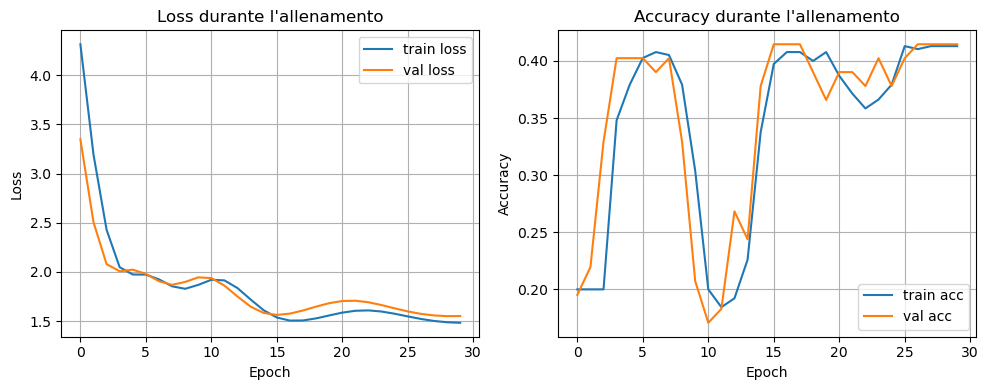

Test accuracy finale: 0.3976


In [48]:

# Plot loss & accuracy
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss durante l'allenamento")
plt.legend(loc="best")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accs, label="train acc")
plt.plot(val_accs, label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy durante l'allenamento")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Valutazione finale sul test set
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_acc = accuracy(test_logits, y_test)
print(f"Test accuracy finale: {test_acc:.4f}")

### Test 2b: Alternative simple classifiers: LogisticRegression / RandomForest / SVM


/opt/homebrew/Caskroom/miniconda/base/envs/daniele_dl_thesis/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression | val acc: 0.280 | test acc: 0.349
RandomForest       | val acc: 0.329 | test acc: 0.386
SVM (RBF)          | val acc: 0.415 | test acc: 0.410

Best model by val acc: SVM_RBF

Classification report (test):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00         8
           3       0.41      1.00      0.58        34
           4       0.00      0.00      0.00        17

    accuracy                           0.41        83
   macro avg       0.08      0.20      0.12        83
weighted avg       0.17      0.41      0.24        83

RandomForest       | val acc: 0.329 | test acc: 0.386
SVM (RBF)          | val acc: 0.415 | test acc: 0.410

Best model by val acc: SVM_RBF

Classification report (test):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
      

/opt/homebrew/Caskroom/miniconda/base/envs/daniele_dl_thesis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/daniele_dl_thesis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/daniele_dl_thesis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

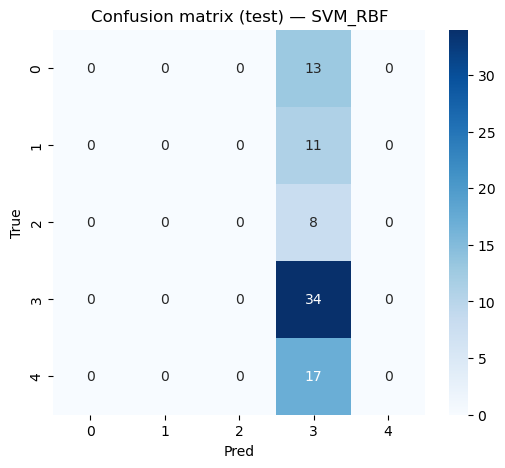

LogisticRegression   | val_acc: 0.280 | test_acc: 0.349
RandomForest         | val_acc: 0.329 | test_acc: 0.386
SVM_RBF              | val_acc: 0.415 | test_acc: 0.410


In [ ]:

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert tensors to numpy if needed
X_tr = X_train.numpy() if hasattr(X_train, 'numpy') else np.array(X_train)
X_v  = X_val.numpy()   if hasattr(X_val, 'numpy')   else np.array(X_val)
X_te = X_test.numpy()  if hasattr(X_test, 'numpy')  else np.array(X_test)

y_tr = y_train.numpy() if hasattr(y_train, 'numpy') else np.array(y_train)

y_v  = y_val.numpy()   if hasattr(y_val, 'numpy')   else np.array(y_val)

y_te = y_test.numpy()  if hasattr(y_test, 'numpy')  else np.array(y_test)

# Standardize features (fit on train)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_v_s  = sc.transform(X_v)
X_te_s = sc.transform(X_te)

results = {}

# 1) Logistic Regression (multiclass, liblinear or saga)
clf_lr = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=2000, random_state=42)
clf_lr.fit(X_tr_s, y_tr)
val_pred = clf_lr.predict(X_v_s)
test_pred = clf_lr.predict(X_te_s)
results['LogisticRegression'] = {
    'val_acc': accuracy_score(y_v, val_pred),
    'test_acc': accuracy_score(y_te, test_pred),
    'clf': clf_lr,
}
print("LogisticRegression | val acc: {:.3f} | test acc: {:.3f}".format(results['LogisticRegression']['val_acc'], results['LogisticRegression']['test_acc']))

# 2) Random Forest
clf_rf = RandomForestClassifier(n_estimators=200, random_state=42)
clf_rf.fit(X_tr, y_tr)
val_pred = clf_rf.predict(X_v)
test_pred = clf_rf.predict(X_te)
results['RandomForest'] = {
    'val_acc': accuracy_score(y_v, val_pred),
    'test_acc': accuracy_score(y_te, test_pred),
    'clf': clf_rf,
}
print("RandomForest       | val acc: {:.3f} | test acc: {:.3f}".format(results['RandomForest']['val_acc'], results['RandomForest']['test_acc']))

# 3) SVM (RBF)
clf_svm = SVC(kernel='rbf', C=1.0, probability=False, random_state=42)
clf_svm.fit(X_tr_s, y_tr)
val_pred = clf_svm.predict(X_v_s)
test_pred = clf_svm.predict(X_te_s)
results['SVM_RBF'] = {
    'val_acc': accuracy_score(y_v, val_pred),
    'test_acc': accuracy_score(y_te, test_pred),
    'clf': clf_svm,
}
print("SVM (RBF)          | val acc: {:.3f} | test acc: {:.3f}".format(results['SVM_RBF']['val_acc'], results['SVM_RBF']['test_acc']))

# Print classification report for best model on test set
best_name = max(results.keys(), key=lambda k: results[k]['val_acc'])
print(f"\nBest model by val acc: {best_name}")
best_clf = results[best_name]['clf']
if best_name in ['LogisticRegression', 'SVM_RBF']:
    y_pred_test = best_clf.predict(X_te_s)
else:
    y_pred_test = best_clf.predict(X_te)

print('\nClassification report (test):')
print(classification_report(y_te, y_pred_test))

# Confusion matrix (test)
cm = confusion_matrix(y_te, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion matrix (test) — {best_name}')
plt.xlabel('Pred')
plt.ylabel('True')
plt.show()

# Summary table
for k, v in results.items():
    print(f"{k:20s} | val_acc: {v['val_acc']:.3f} | test_acc: {v['test_acc']:.3f}")



In [52]:
# informazioni generali
print(type(graphs), len(graphs))
print("Esempio graph object:", type(graphs[0]))

# dettagli sul primo grafo
g0 = graphs[0]
print("g0.x shape, dtype:", g0.x.shape, g0.x.dtype)
print("g0.edge_index shape:", g0.edge_index.shape)
if hasattr(g0, 'y'):
    print("g0.y shape/dtype:", g0.y.shape, g0.y.dtype)

# tensori di dataset
print("X type/shape:", type(X), getattr(X, 'shape', None))
print("X_train type/shape:", type(X_train), getattr(X_train, 'shape', None))

<class 'list'> 38562
Esempio graph object: <class 'torch_geometric.data.data.Data'>
g0.x shape, dtype: torch.Size([61, 40]) torch.float32
g0.edge_index shape: torch.Size([2, 276])
g0.y shape/dtype: torch.Size([1]) torch.int64
X type/shape: <class 'torch.Tensor'> torch.Size([61, 40])
X_train type/shape: <class 'torch.Tensor'> torch.Size([385, 40])
